### Importing libraries

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from matplotlib.patches import Patch
from collections import defaultdict

sns.set_theme(style='darkgrid')

In [27]:
# Loading data
data = pd.read_csv('Linhac24-25_Sportlogiq.csv')
sorted_data = data.sort_values(by=['gameid', 'compiledgametime']).copy()

print(f'Rows: {len(data):,}')
print(f'Games: {data["gameid"].nunique()}')
print(f'Teams: {data["teamid"].nunique()}\n')
print(data['manpowersituation'].value_counts())

Rows: 541,802
Games: 156
Teams: 14

manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64


In [28]:
# Check missing values
data.isnull().sum()

gameid                                0
opposingteamgoalieoniceid          3266
opposingteamid                        0
playerid                              0
teamgoalieoniceid                  7080
teamid                                0
teaminpossession                  73890
currentpossession                 73890
xg_allattempts                   525454
compiledgametime                      0
eventname                             0
ishomegame                            0
manpowersituation                     0
opposingteamskatersonicecount         0
outcome                               0
period                                0
playerprimaryposition                 0
scoredifferential                     0
teamskatersonicecount                 0
type                                  0
xadjcoord                             0
yadjcoord                             0
dtype: int64

# What separates PP sequences that lead to goals from those that don't

#### Each PP sequence is split by gaps > 10s. Features extracted per sequence: passes, carries, duration, zone entries, shots.

In [29]:
# If more than 10 seconds pass between recorded events, start a new sequence
pp_seq_features = []

# Loop over each game
for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    
    # Filter to powerplay events only
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue

    # Identify gaps between events and split into sequences
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()

    # Loop over each sequence
    for seq_id, seq in pp.groupby('seq_id'):
        if len(seq) < 3: continue  # Skip very short sequences

        # Get first controlled zone entry (if there are any)
        entries = seq[seq['eventname'] == 'controlledentry']['type']
        if len(entries) > 0:
            t = entries.iloc[0]
            entry_type = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')
        else:
            entry_type = 'no_entry'

        # Store sequence-level features
        pp_seq_features.append({
            'teamid':    seq['teamid'].mode()[0],  # Most common team in sequence
            'goal':      int((seq['eventname'] == 'goal').any()),
            'n_passes':  (seq['eventname'] == 'pass').sum(),
            'n_carries': (seq['eventname'] == 'carry').sum(),
            'n_shots':   seq['eventname'].isin(['shot', 'goal']).sum(),
            'n_entries': (seq['eventname'] == 'controlledentry').sum(),
            'duration':  seq['compiledgametime'].max() - seq['compiledgametime'].min(),
            'entry_type': entry_type,
            'mean_xg':   seq['xg_allattempts'].mean() if seq['xg_allattempts'].notna().any() else 0,
        })

# Convert to DataFrame
seq_df = pd.DataFrame(pp_seq_features)

print(f'Total PP sequences: {len(seq_df)}')
print(f'Goal sequences: {seq_df["goal"].sum()} ({seq_df["goal"].mean()*100:.1f}%)')
print(f'No-goal sequences:  {(1-seq_df["goal"]).sum()}\n')
print(seq_df.groupby('goal')[['n_passes','n_carries','n_shots','duration','mean_xg']].mean().round(2))

Total PP sequences: 962
Goal sequences: 184 (19.1%)
No-goal sequences:  778

      n_passes  n_carries  n_shots  duration  mean_xg
goal                                                 
0        20.55       4.17     2.39     82.73     0.04
1        18.93       2.74     4.12     66.73     0.12


In [30]:
# Individual events from each PP sequence that contains a goal
goal_seqs = []
gid = 0  # Unique ID for each goal sequence

# Loop over each game
for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime')
    
    # Filter to power play events
    pp = game_df[game_df['manpowersituation'] == 'powerPlay'].copy()
    if len(pp) == 0: continue

    # Split into sequences based on time gaps
    pp['time_gap'] = pp['compiledgametime'].diff()
    pp['new_seq']  = (pp['time_gap'] > 10) | pp['time_gap'].isna()
    pp['seq_id']   = pp['new_seq'].cumsum()

    # Loop over sequences
    for seq_id, seq in pp.groupby('seq_id'):
        # Keep only sequences with at least 3 events and a goal
        if len(seq) >= 3 and (seq['eventname'] == 'goal').any():
            s = seq.copy()
            s['goal_id'] = gid  # Assign sequence ID
            goal_seqs.append(s)
            gid += 1

# Combine all goal sequences into one DataFrame
pp_sequences = pd.concat(goal_seqs, ignore_index=True)

print(f'PP goal sequences: {pp_sequences["goal_id"].nunique()}')
print(pp_sequences['eventname'].value_counts().head(8))

PP goal sequences: 184
eventname
pass              3483
reception         3178
lpr               1209
shot               569
carry              504
assist             367
faceoff            299
controlledexit     281
Name: count, dtype: int64


### Example PP goal sequence

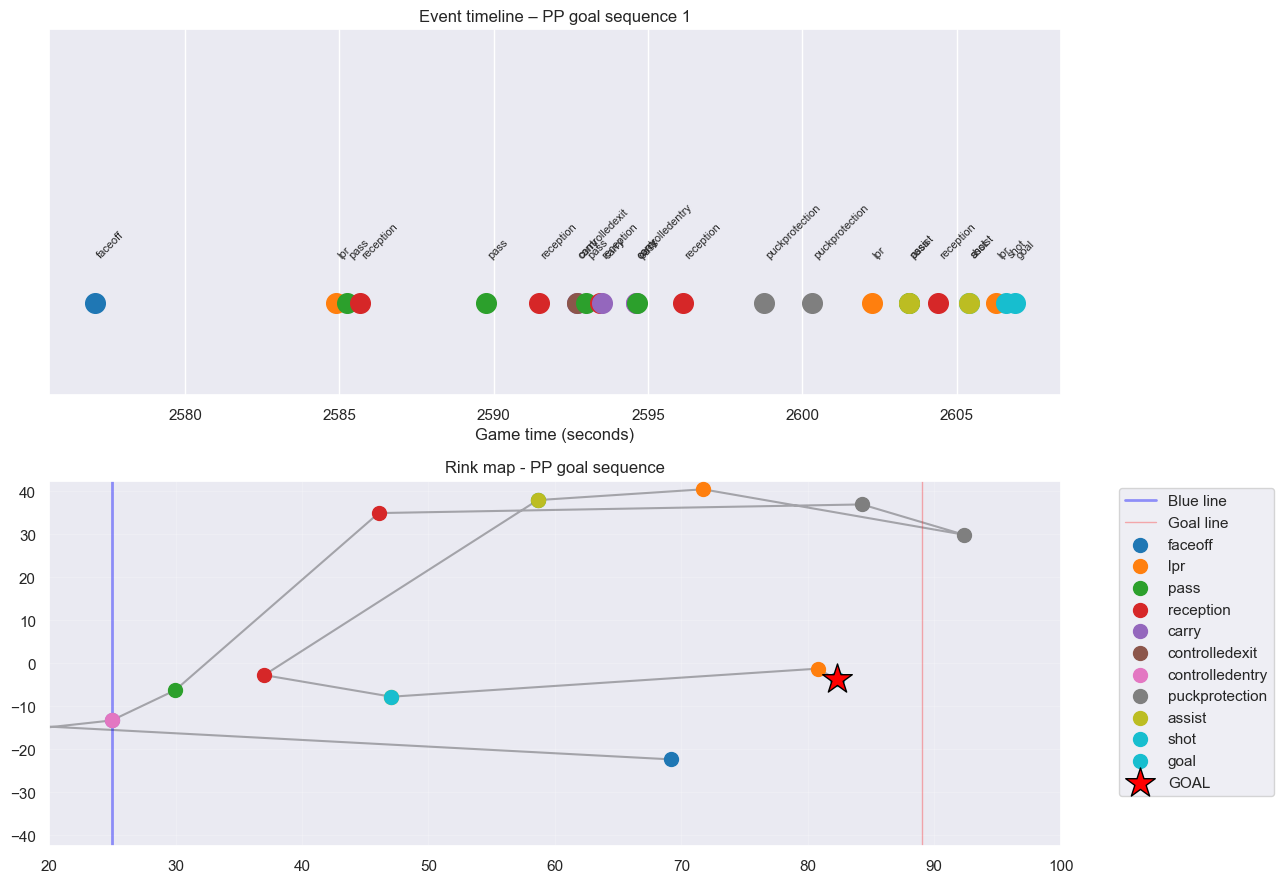

In [31]:
# Plots of PP goal sequences
goal_id_to_plot = 1
single_seq = pp_sequences[pp_sequences['goal_id'] == goal_id_to_plot]

evts = single_seq['eventname'].unique()
cmap = plt.cm.tab10
colors_map = {e: cmap(i / max(len(evts) - 1, 1)) for i, e in enumerate(evts)}

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Event timeline
ax = axes[0]
for _, row in single_seq.iterrows():
    ax.scatter(row['compiledgametime'], 1, color=colors_map[row['eventname']], s=200, zorder=3)
    ax.text(row['compiledgametime'], 1.05, row['eventname'], rotation=45, ha='left', fontsize=8)
ax.set_title(f'Event timeline – PP goal sequence {goal_id_to_plot}')
ax.set_xlabel('Game time (seconds)'); ax.set_yticks([]); ax.set_ylim(0.9, 1.3)

# Rink map
ax = axes[1]
ax.axvline(25, color='blue', linewidth=2, alpha=0.4, label='Blue line')
ax.axvline(89, color='red', linewidth=1, alpha=0.3, label='Goal line')
ax.plot(single_seq['xadjcoord'], single_seq['yadjcoord'], color='black', alpha=0.3, zorder=1)
for evt in evts:
    sub = single_seq[single_seq['eventname'] == evt]
    ax.scatter(sub['xadjcoord'], sub['yadjcoord'], label=evt, s=100, zorder=3, color=colors_map[evt])
goal_row = single_seq[single_seq['eventname'] == 'goal']
if not goal_row.empty:
    ax.scatter(goal_row['xadjcoord'], goal_row['yadjcoord'],
               color='red', marker='*', s=500, label='GOAL', zorder=5, edgecolors='black')
ax.set_xlim(20, 100); ax.set_ylim(-42.5, 42.5)
ax.set_title('Rink map - PP goal sequence')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.2)
plt.tight_layout(); plt.show()

### Last 10 events before a PP goal

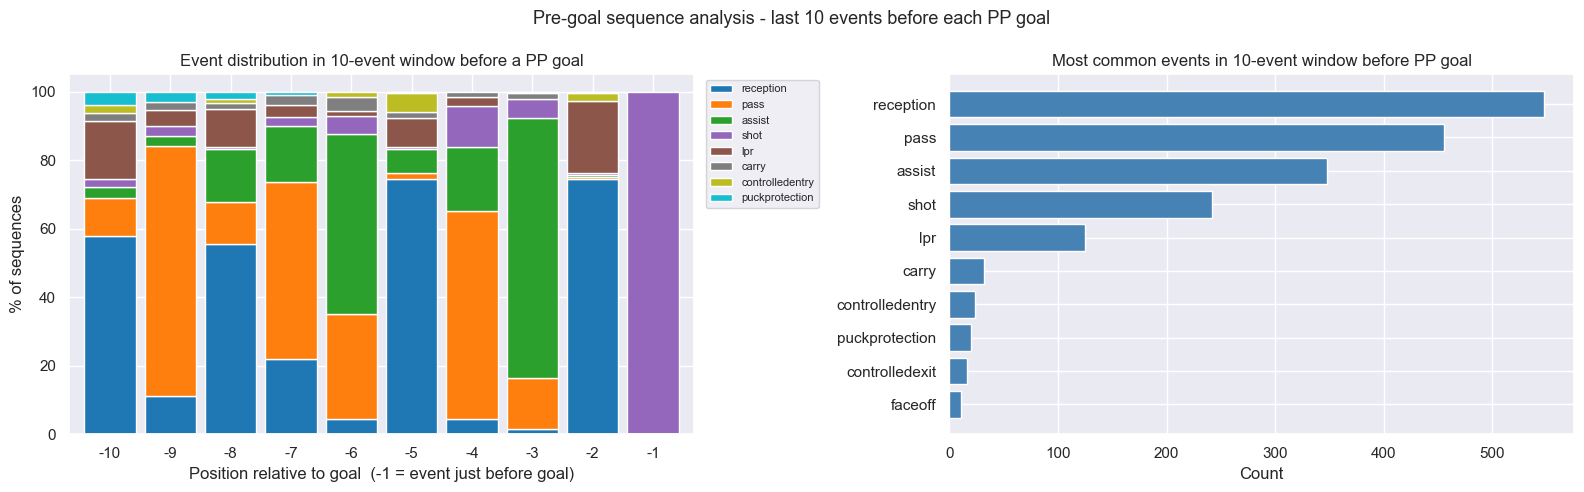

Event counts in 10-event pre-goal window:
eventname
reception          548
pass               456
assist             348
shot               242
lpr                125
carry               32
controlledentry     24
puckprotection      20
controlledexit      16
faceoff             11
Name: count, dtype: int64


In [32]:
# Build a record for every event in the 10-event window before each PP goal
pre_goal_records = []

# Loop over each goal sequence
for goal_id, seq in pp_sequences.groupby('goal_id'):
    seq = seq.sort_values('compiledgametime')
    
    # Find the goal event
    goal_row = seq[seq['eventname'] == 'goal']
    if goal_row.empty:
        continue
    goal_time = goal_row['compiledgametime'].iloc[0]

    # Keep only events before the goal and take last 10 events before
    pre = seq[seq['compiledgametime'] < goal_time]
    last_10 = pre.tail(10).reset_index(drop=True)
    n = len(last_10)

    # Store events relative to goal position
    for i, (_, row) in enumerate(last_10.iterrows()):
        pre_goal_records.append({
            'goal_id': goal_id,
            'pos': i - n,
            'eventname': row['eventname'],
        })

pre_goal_df = pd.DataFrame(pre_goal_records)

# Count event frequencies
freq = pre_goal_df['eventname'].value_counts()
top_events = freq.head(8).index.tolist()

pivot = pre_goal_df.pivot_table(index='pos', columns='eventname', aggfunc='size', fill_value=0)
pivot_pct = pivot[top_events].div(pivot[top_events].sum(axis=1), axis=0) * 100

# Plot events occuring before goal in PP
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pivot_pct.plot(kind='bar', stacked=True, ax=axes[0], colormap='tab10', width=0.85)
axes[0].set_xlabel('Position relative to goal  (-1 = event just before goal)')
axes[0].set_ylabel('% of sequences')
axes[0].set_title('Event distribution in 10-event window before a PP goal')
axes[0].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
axes[0].tick_params(axis='x', rotation=0)

# Overall event frequency
axes[1].barh(freq.index[:10][::-1], freq.values[:10][::-1], color='steelblue', edgecolor='white')
axes[1].set_xlabel('Count')
axes[1].set_title('Most common events in 10-event window before PP goal')

plt.suptitle('Pre-goal sequence analysis - last 10 events before each PP goal', fontsize=13)
plt.tight_layout()
plt.show()

print('Event counts in 10-event pre-goal window:')
print(freq.head(10))

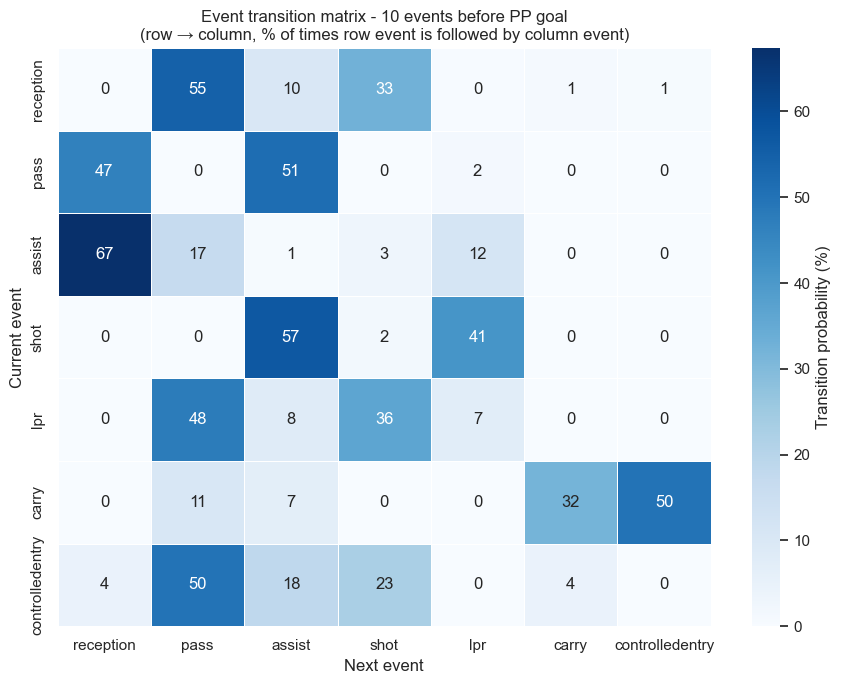

In [33]:
# Build transition counts between consecutive events
transitions = defaultdict(lambda: defaultdict(int))
for goal_id, grp in pre_goal_df.groupby('goal_id'):
    evts = grp.sort_values('pos')['eventname'].tolist()
    for a, b in zip(evts[:-1], evts[1:]):
        transitions[a][b] += 1

# Keep top 7 most common events
top7 = freq.head(7).index.tolist()

# Create transition matrix
trans_matrix = pd.DataFrame(
    {col: [transitions[row][col] for row in top7] for col in top7},
    index=top7
)

# Convert to row-wise percentages
trans_pct = trans_matrix.div(trans_matrix.sum(axis=1).replace(0, np.nan), axis=0) * 100

# Plot transition heatmap
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(trans_pct.fillna(0).round(1), annot=True, fmt='.0f', cmap='Blues', ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Transition probability (%)'})

ax.set_title('Event transition matrix - 10 events before PP goal\n(row → column, % of times row event is followed by column event)')
ax.set_xlabel('Next event')
ax.set_ylabel('Current event')

plt.tight_layout()
plt.show()

### Clustering PP goal sequences

Average features per cluster:
         x_mean  x_min  y_std  num_passes  num_carries  total_events  duration
cluster                                                                       
0         58.90  28.01  21.22        8.78         0.04         26.65     24.29
1         39.77 -83.85  25.18       30.60         4.36         91.50    107.75
2         26.91 -85.03  24.55       12.80         2.65         42.21     50.05


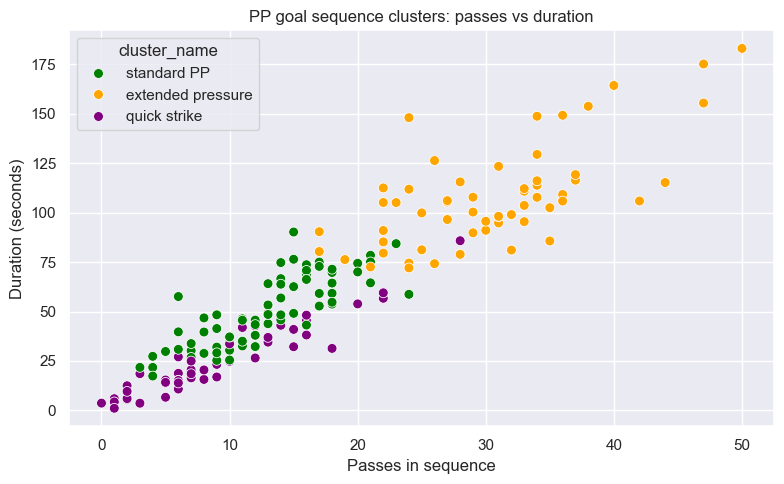

In [34]:
# Create sequence-level features for each goal sequence
def create_seq_features(df_seqs):
    return df_seqs.groupby('goal_id').agg(
        x_mean=('xadjcoord', 'mean'), # Average x-position
        x_min=('xadjcoord', 'min'),   # Closest x-position to goal
        y_std=('yadjcoord', 'std'),   # Spread in y-direction
        num_passes=('eventname', lambda x: (x == 'pass').sum()),   # Count passes
        num_carries=('eventname', lambda x: (x == 'carry').sum()), # Count carries
        total_events=('eventname', 'count'),   # Total events in sequence
        duration=('compiledgametime', lambda x: x.max() - x.min())  # Sequence length
    ).fillna(0)

# Build feature matrix and standardize features
seq_feat_df = create_seq_features(pp_sequences)
seq_feat_df = seq_feat_df[
    (seq_feat_df['duration'] <= 200)
].copy()
X_seq = StandardScaler().fit_transform(seq_feat_df)

# Cluster sequences into 3 groups
seq_feat_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X_seq)

# Attach cluster labels back to event-level data
if 'cluster' in pp_sequences.columns:
    pp_sequences = pp_sequences.drop(columns=['cluster'])
pp_sequences = pp_sequences.merge(seq_feat_df['cluster'].reset_index(), on='goal_id', how='left')

print('Average features per cluster:')
print(seq_feat_df.groupby('cluster').mean().round(2))

# Visualize clusters (passes vs duration)
fig, ax = plt.subplots(figsize=(8, 5))

ordered_cluster_id = seq_feat_df.groupby('cluster')['duration'].mean().sort_values().index.tolist()

# Give names to the clusters
cluster_names = {
    ordered_cluster_id[0]: 'quick strike',
    ordered_cluster_id[1]: 'standard PP',
    ordered_cluster_id[2]: 'extended pressure'
}
seq_feat_df['cluster_name'] = seq_feat_df['cluster'].map(cluster_names)

sns.scatterplot(
    data=seq_feat_df,
    x='num_passes',
    y='duration',
    hue='cluster_name',
    palette={
        'quick strike': 'purple',
        'standard PP': 'green',
        'extended pressure': 'orange'},
    s=50,
    ax=ax
)

ax.set_title('PP goal sequence clusters: passes vs duration')
ax.set_xlabel('Passes in sequence'); ax.set_ylabel('Duration (seconds)')

plt.tight_layout()
plt.show()

# Zone entry type

### Shot quality after each entry type

             count    mean     std     min     25%     50%     75%     max
entry_type                                                                
carry       1577.0  0.0696  0.0929  0.0015  0.0120  0.0348  0.0947  0.7765
faceoff      310.0  0.0809  0.1112  0.0016  0.0102  0.0336  0.1117  0.7440
pass         542.0  0.0651  0.0864  0.0014  0.0109  0.0346  0.0844  0.6902


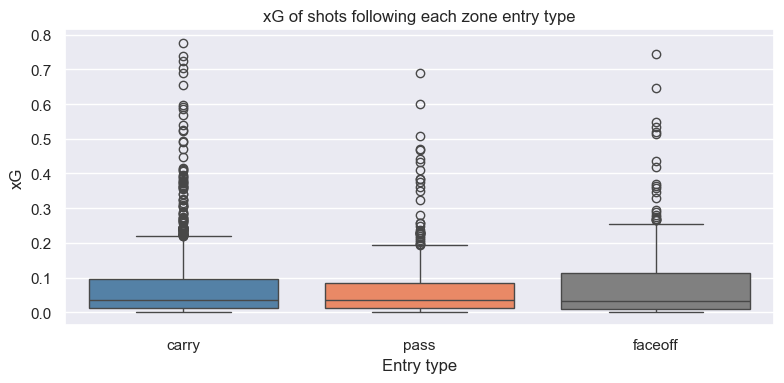

In [35]:
# Filter to power play data and sort by game and time
pp_data = data[data['manpowersituation'] == 'powerPlay'].copy().sort_values(['gameid', 'compiledgametime'])

# Create sequences based on time gaps within each game
pp_data['time_gap'] = pp_data.groupby('gameid')['compiledgametime'].diff()
pp_data['new_seq']  = (pp_data['time_gap'] > 10) | pp_data['time_gap'].isna()
pp_data['seq_id']   = pp_data.groupby('gameid')['new_seq'].cumsum()

tagged = []

# Loop through each game and sequence
for (game, seq), grp in pp_data.groupby(['gameid', 'seq_id']):
    
    # Identify entry type for the sequence
    entries = grp[grp['eventname'] == 'controlledentry']['type']
    if len(entries) == 0:
        etype = 'faceoff'
    else:
        t = entries.iloc[0]
        etype = 'carry' if str(t).startswith('carry') else ('pass' if str(t).startswith('pass') else 'other')

    # Keep only shots and goals with xG values
    shots = grp[grp['eventname'].isin(['shot', 'goal'])].dropna(subset=['xg_allattempts']).copy()
    
    # Assign entry type to each shot
    shots['entry_type'] = etype
    
    tagged.append(shots)

# Combine all tagged shots
tagged_shots = pd.concat(tagged, ignore_index=True)

print(tagged_shots.groupby('entry_type')['xg_allattempts'].describe().round(4))

# Plot xG distribution by entry type
fig, ax = plt.subplots(figsize=(8, 4))

order = ['carry', 'pass', 'other', 'faceoff']
order = [o for o in order if o in tagged_shots['entry_type'].unique()]

sns.boxplot(
    data=tagged_shots,
    x='entry_type',
    y='xg_allattempts',
    hue='entry_type',
    order=order,
    palette={
        'carry': 'steelblue',
        'pass': 'coral',
        'other': 'mediumseagreen',
        'faceoff': 'gray'},
    dodge=False,
    legend=False,
    ax=ax
)

ax.set_title('xG of shots following each zone entry type')
ax.set_xlabel('Entry type')
ax.set_ylabel('xG')

plt.tight_layout()
plt.show()

# Puck movement and shot quality

#### Passes by the attacking team in the 10 seconds before each shot (same team in possession).

In [36]:
# Filter shots and goals with valid xG and possession info
shots = pp_data[pp_data['eventname'].isin(['shot', 'goal'])].dropna(
    subset=['xg_allattempts', 'teaminpossession']
).copy()

# Extract all passes with timestamps
passes_df = pp_data[pp_data['eventname'] == 'pass'][
    ['gameid', 'teaminpossession', 'compiledgametime']
].dropna(subset=['teaminpossession']).copy().rename(columns={'compiledgametime': 'pass_time'})

counts = []

for game_id, g_shots in shots.groupby('gameid'):
    g_passes = passes_df[passes_df['gameid'] == game_id]

    for _, row in g_shots.iterrows():
        
        # Get all passes from same team in possession
        tp = g_passes[g_passes['teaminpossession'] == row['teaminpossession']]['pass_time'].values
        t = row['compiledgametime'] # Shot time

        # Count passes in the 10 seconds before the shot
        counts.append(int(((tp >= t - 10) & (tp < t)).sum()))

# Add feature to dataset
shots['passes_before'] = counts
shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(10)

,mean,count
passes_before,,
0,0.050547,24
1,0.045053,174
2,0.056487,427
3,0.070210,622
4,0.073386,612
5,0.083210,379
6,0.092262,151
7,0.070081,38
8,0.032160,1


### Mann-Whitney U test (few, medium and many passes before shot)

In [37]:
# Define more balanced groups
low  = shots[shots['passes_before'] <= 2]['xg_allattempts']
mid  = shots[(shots['passes_before'] >= 3) & (shots['passes_before'] <= 6)]['xg_allattempts']
high = shots[shots['passes_before'] >= 7]['xg_allattempts']

# Mann-Whitney U tests between groups
stat_lh, p_lh = stats.mannwhitneyu(low, high, alternative='two-sided')
stat_lm, p_lm = stats.mannwhitneyu(low, mid, alternative='two-sided')
stat_mh, p_mh = stats.mannwhitneyu(mid, high, alternative='two-sided')

print(f'LOW (≤2):   n={len(low)},  median xG={low.median():.4f}')
print(f'MID (3-6):  n={len(mid)},  median xG={mid.median():.4f}')
print(f'HIGH (≥7):  n={len(high)}, median xG={high.median():.4f}')
print()

# Statistical tests
print(f'Low vs High: U={stat_lh:.0f}, p={p_lh:.4f}')
print(f'Low vs Mid:  U={stat_lm:.0f}, p={p_lm:.4f}')
print(f'Mid vs High: U={stat_mh:.0f}, p={p_mh:.4f}')

# Interpretation 
if p_lh < 0.05:
    print('\nSignificant difference between LOW and HIGH groups (p < 0.05)')
else:
    print('\nNo significant difference between LOW and HIGH groups (p ≥ 0.05)')

LOW (≤2):   n=625,  median xG=0.0272
MID (3-6):  n=1764,  median xG=0.0397
HIGH (≥7):  n=40, median xG=0.0352

Low vs High: U=10942, p=0.1861
Low vs Mid:  U=466001, p=0.0000
Mid vs High: U=36574, p=0.6913

No significant difference between LOW and HIGH groups (p ≥ 0.05)


### Bootstrap 95% CI on mean xG per pass count

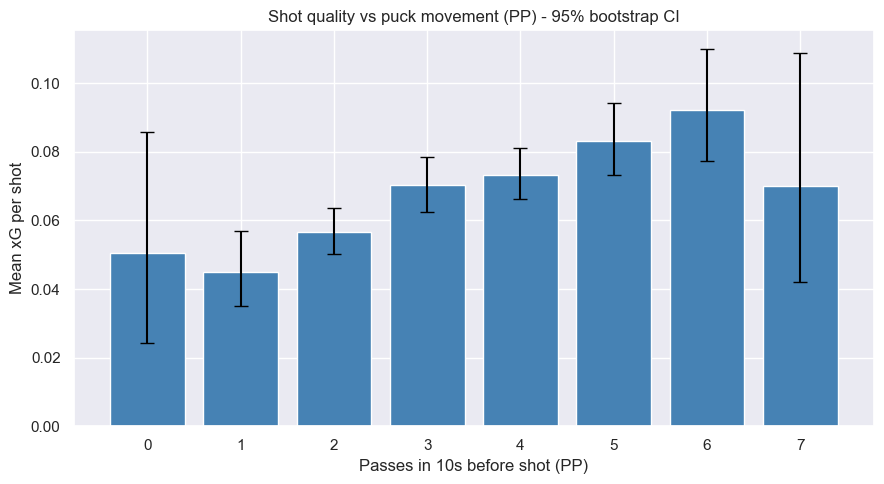

 passes   n  mean_xg  ci_lo  ci_hi
      0  24   0.0505 0.0242 0.0857
      1 174   0.0451 0.0350 0.0569
      2 427   0.0565 0.0501 0.0637
      3 622   0.0702 0.0624 0.0784
      4 612   0.0734 0.0664 0.0812
      5 379   0.0832 0.0733 0.0942
      6 151   0.0923 0.0773 0.1099
      7  38   0.0701 0.0421 0.1089


In [38]:
# Compute bootstrap confidence interval for mean xG
def bootstrap_ci(arr, n_boot=2000):
    arr = np.asarray(arr)
    
    # Resample with replacement and compute mean each time
    means = [
        np.random.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)]
    
    # 95% confidence interval (2.5% to 97.5%)
    return np.percentile(means, [2.5, 97.5])

rows = []

# Loop over number of passes before shot
for n in range(0, 8):
    # Filter shots with exactly n preceding passes
    sub = shots[shots['passes_before'] == n]['xg_allattempts']
    
    # Skip if too few samples
    if len(sub) < 10:
        continue

    lo, hi = bootstrap_ci(sub) # Compute bootstrap CI
    
    rows.append({
        'passes': n,
        'n': len(sub),
        'mean_xg': sub.mean(),
        'ci_lo': lo,
        'ci_hi': hi })

ci_df = pd.DataFrame(rows)

# Plot mean xG with confidence intervals
fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(ci_df['passes'], ci_df['mean_xg'], color='steelblue', edgecolor='white')

ax.errorbar(
    ci_df['passes'],
    ci_df['mean_xg'],
    yerr=[ci_df['mean_xg'] - ci_df['ci_lo'], ci_df['ci_hi'] - ci_df['mean_xg']],
    fmt='none',
    color='black',
    capsize=5,
    linewidth=1.5
)

ax.set_xlabel('Passes in 10s before shot (PP)')
ax.set_ylabel('Mean xG per shot')
ax.set_title('Shot quality vs puck movement (PP) - 95% bootstrap CI')
plt.tight_layout()
plt.show()

print(ci_df[['passes', 'n', 'mean_xg', 'ci_lo', 'ci_hi']].round(4).to_string(index=False))

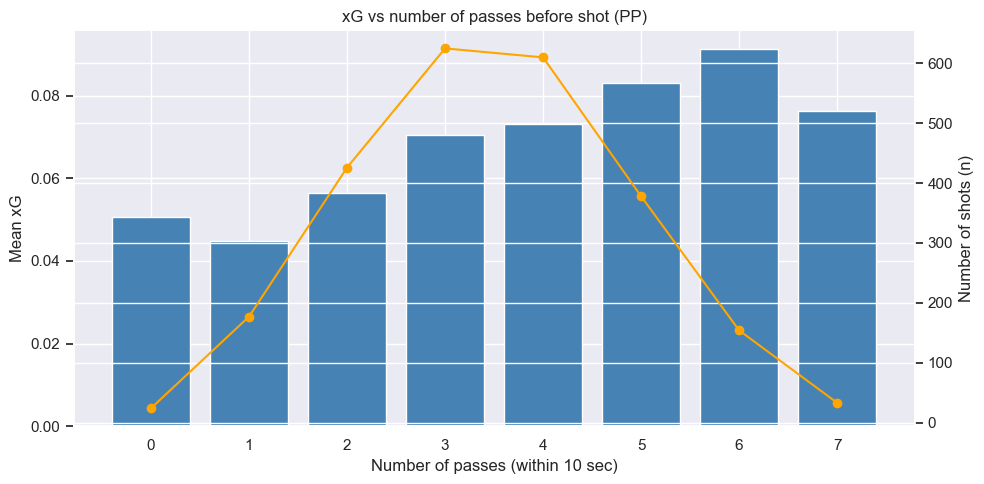

' Plot\nBlue: Shots on goal by number of passes (0-7) and their mean Expected Goal value. Shot quality increases with more passes.\nOrange: Number of shots, most shots come after 3-4 passes. Few shots at 0-1 or 6+ passes.\nxG increases up to around 6 passes during the PP, then drops (only values with more than 10 observations shown).\n'

In [39]:
# Count passes within 10 seconds before each shot during the powerplay
pp_shots = data[(data['manpowersituation'] == 'powerPlay') &
                (data['eventname'].isin(['shot', 'goal']))].copy()

def count_recent_passes(row):
    mask = (data['gameid'] == row['gameid']) &\
           (data['compiledgametime'] < row['compiledgametime']) &\
           (data['compiledgametime'] > row['compiledgametime'] - 10) &\
           (data['eventname'] == 'pass') &\
           (data['manpowersituation'] == 'powerPlay')
    return mask.sum()

pp_shots['passes_before'] = pp_shots.apply(count_recent_passes, axis=1)
pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).head(15)

# Plot number of shots and their expected goal value against number of passes.
agg = pp_shots.groupby('passes_before')['xg_allattempts'].agg(['mean', 'count']).reset_index()
agg = agg[agg['count'] >= 10]  # Filter out low sample sizes

fig, ax1 = plt.subplots(figsize=(10, 5))
ax1.bar(agg['passes_before'], agg['mean'], color='steelblue', label='Mean xG')
ax1.set_xlabel('Number of passes (within 10 sec)')
ax1.set_ylabel('Mean xG')
ax1.set_title('xG vs number of passes before shot (PP)')

ax2 = ax1.twinx()
ax2.plot(agg['passes_before'], agg['count'], color='orange', marker='o', label='Number of shots')
ax2.set_ylabel('Number of shots (n)')

plt.tight_layout()
plt.show()

""" Plot
Blue: Shots on goal by number of passes (0-7) and their mean Expected Goal value. Shot quality increases with more passes.
Orange: Number of shots, most shots come after 3-4 passes. Few shots at 0-1 or 6+ passes.
xG increases up to around 6 passes during the PP, then drops (only values with more than 10 observations shown).
"""


### Shot location heatmap in PP, where do shots and goals originate?

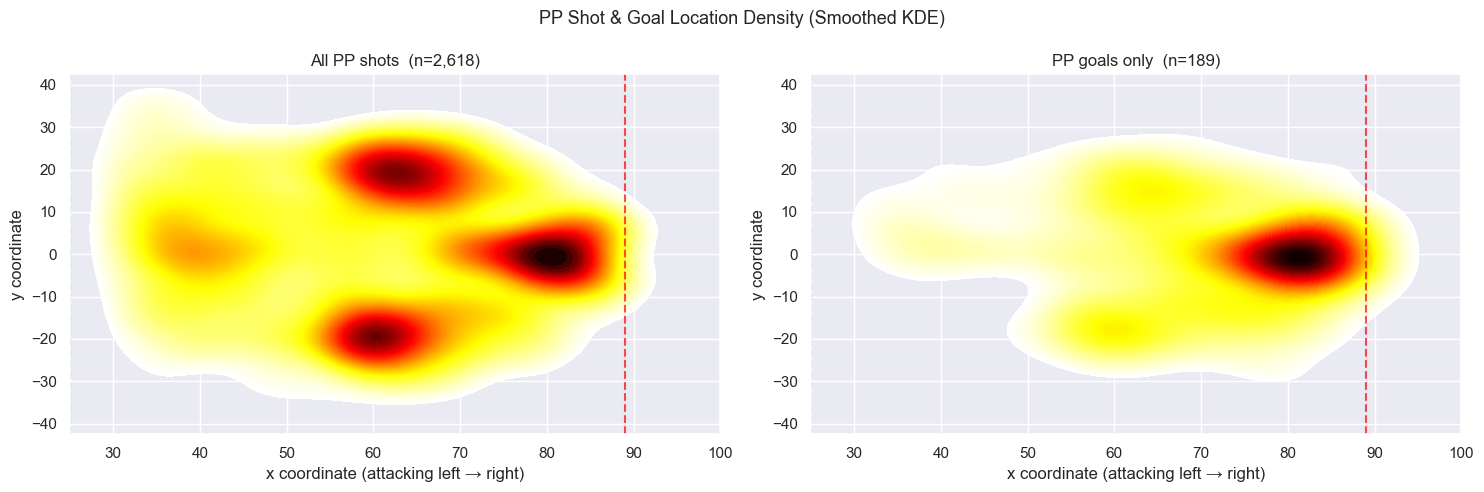

In [40]:
import seaborn as sns

pp_shots_loc = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'].isin(['shot', 'goal']))
].dropna(subset=['xadjcoord', 'yadjcoord'])

pp_goals_loc = pp_shots_loc[pp_shots_loc['eventname'] == 'goal']

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, subset, title in zip(axes, [pp_shots_loc, pp_goals_loc],
    [f'All PP shots  (n={len(pp_shots_loc):,})', f'PP goals only  (n={len(pp_goals_loc)})']):
    sns.kdeplot(
        data=subset,
        x='xadjcoord',
        y='yadjcoord',
        fill=True,
        cmap='hot_r',
        levels=100,
        thresh=0.05,
        bw_adjust=0.8,  
        ax=ax
    )

    ax.axvline(25, color='dodgerblue', linewidth=1.5, alpha=0.7, linestyle='--')
    ax.axvline(89, color='red', linewidth=1.5, alpha=0.7, linestyle='--')

    ax.set_xlim(25, 100)
    ax.set_ylim(-42.5, 42.5)

    ax.set_title(title)
    ax.set_xlabel('x coordinate (attacking left → right)')
    ax.set_ylabel('y coordinate')

plt.suptitle('PP Shot & Goal Location Density (Smoothed KDE)', fontsize=13)
plt.tight_layout()
plt.show()

# When in the PP do goals happen?

### PP goals by period × 5-minute segment

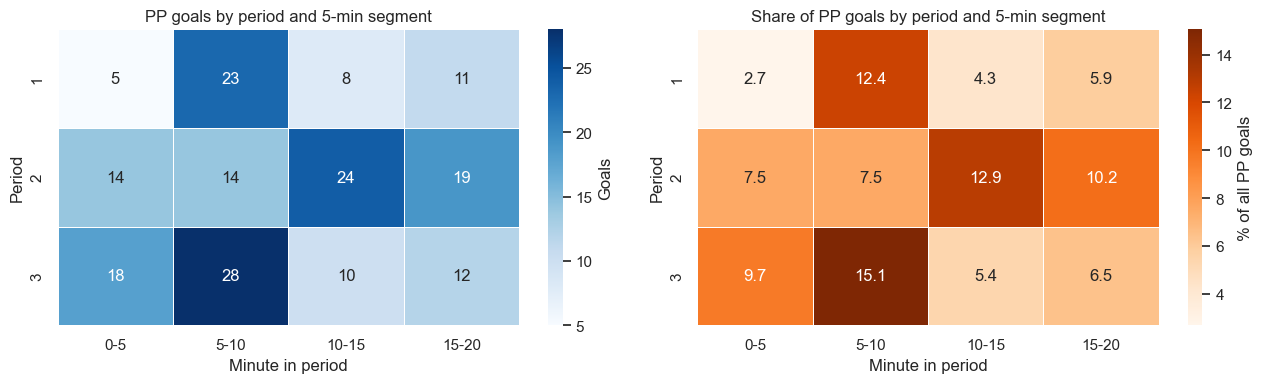

In [41]:
pp_goals_time = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'goal') &
    (data['period'].isin([1, 2, 3]))
].copy()

pp_goals_time['time_in_period_s'] = pp_goals_time['compiledgametime'] - (pp_goals_time['period'] - 1) * 1200
pp_goals_time['minute_in_period']  = pp_goals_time['time_in_period_s'] / 60
pp_goals_time['5min_bin']          = (pp_goals_time['minute_in_period'] // 5 * 5).clip(0, 15).astype(int)
pp_goals_time['5min_label']        = pp_goals_time['5min_bin'].astype(str) + '-' + (pp_goals_time['5min_bin'] + 5).astype(str)

# Define time bins (5-minute segments within periods)
bin_labels = ['0-5', '5-10', '10-15', '15-20']

# Count PP goals by period and time segment
goal_matrix = pp_goals_time.groupby(['period', '5min_label']).size().unstack(fill_value=0)
goal_matrix = goal_matrix.reindex(columns=bin_labels, fill_value=0)

# Convert counts to percentage of total goals
share_matrix = (goal_matrix / goal_matrix.values.sum() * 100).round(2)

# Plot raw goal counts and percentage share
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(
    goal_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0],
    linewidths=0.5,
    cbar_kws={'label': 'Goals'})

axes[0].set_title('PP goals by period and 5-min segment')
axes[0].set_xlabel('Minute in period')
axes[0].set_ylabel('Period')

# Share of total goals
sns.heatmap(
    share_matrix,
    annot=True,
    fmt='.1f',
    cmap='Oranges',
    ax=axes[1],
    linewidths=0.5,
    cbar_kws={'label': '% of all PP goals'})

axes[1].set_title('Share of PP goals by period and 5-min segment')
axes[1].set_xlabel('Minute in period')
axes[1].set_ylabel('Period')

plt.tight_layout()
plt.show()

### Score differential when PP goal is scored

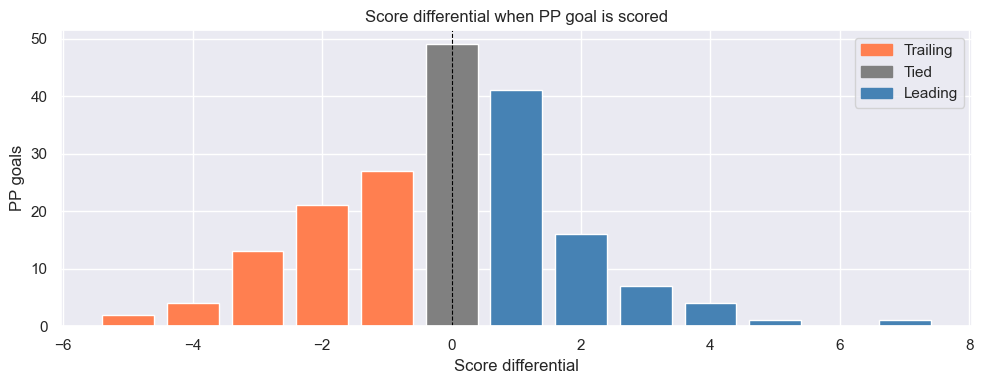

In [42]:
# Count PP goals by score differential
score_counts = pp_goals_time['scoredifferential'].value_counts().sort_index()

# Color bars based on game state
colors = [
    'coral' if x < 0 else 'steelblue' if x > 0 else 'gray'
    for x in score_counts.index]

# Plot distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    score_counts.index,
    score_counts.values,
    color=colors,
    edgecolor='white')

ax.set_title('Score differential when PP goal is scored')
ax.set_xlabel('Score differential')
ax.set_ylabel('PP goals')

# Reference line at even score
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')

ax.legend(handles=[
    Patch(color='coral', label='Trailing'),
    Patch(color='gray', label='Tied'),
    Patch(color='steelblue', label='Leading')
])

plt.tight_layout()
plt.show()

# Team PP analysis

#### PP conversion rate per team

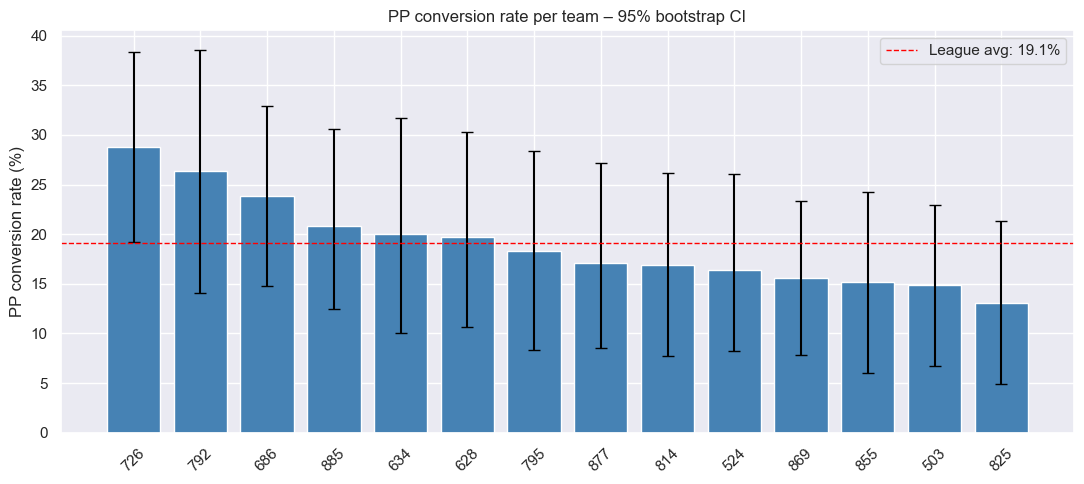

 teamid    pp_pct  n     ci_lo     ci_hi
    726 28.767123 73 19.178082 38.356164
    792 26.315789 57 14.035088 38.596491
    686 23.863636 88 14.772727 32.954545
    885 20.833333 72 12.500000 30.555556
    634 20.000000 60 10.000000 31.666667
    628 19.696970 66 10.606061 30.303030
    795 18.333333 60  8.333333 28.333333
    877 17.142857 70  8.571429 27.142857
    814 16.923077 65  7.692308 26.153846
    524 16.438356 73  8.219178 26.027397
    869 15.584416 77  7.792208 23.376623
    855 15.151515 66  6.060606 24.242424
    503 14.864865 74  6.756757 22.972973
    825 13.114754 61  4.918033 21.311475


In [43]:
# Compute PP conversion rate per team
team_conv_df = seq_df.groupby('teamid').agg(
    pp_pct=('goal', lambda x: x.mean() * 100), 
    n=('goal', 'count') 
).reset_index()

# Bootstrap function to estimate confidence interval for conversion rate
def bootstrap_rate_ci(arr, n_boot=1000):
    arr = np.array(arr)
    
    # Resample and compute mean each time
    means = [
        np.random.choice(arr, size=len(arr), replace=True).mean()
        for _ in range(n_boot)]
    
    # 95% confidence interval
    return np.percentile(means, 2.5) * 100, np.percentile(means, 97.5) * 100

# Compute CI for each team
cis = [
    bootstrap_rate_ci(seq_df[seq_df['teamid'] == t]['goal'].values)
    for t in team_conv_df['teamid']]

team_conv_df['ci_lo'] = [c[0] for c in cis]
team_conv_df['ci_hi'] = [c[1] for c in cis]

# Sort teams by PP efficiency
team_conv_df = team_conv_df.sort_values('pp_pct', ascending=False)

# Plot results
fig, ax = plt.subplots(figsize=(11, 5))
x = range(len(team_conv_df))

# Bar plot: PP conversion rate
ax.bar(x, team_conv_df['pp_pct'], color='steelblue', edgecolor='white')

# Error bars: bootstrap confidence intervals
ax.errorbar(
    x,
    team_conv_df['pp_pct'],
    yerr=[
        team_conv_df['pp_pct'] - team_conv_df['ci_lo'],
        team_conv_df['ci_hi'] - team_conv_df['pp_pct']
    ],
    fmt='none',
    color='black',
    capsize=4,
    linewidth=1.5)
ax.set_xticks(x)
ax.set_xticklabels(team_conv_df['teamid'], rotation=45)
ax.set_ylabel('PP conversion rate (%)')
ax.set_title('PP conversion rate per team – 95% bootstrap CI')

# League average reference line
ax.axhline(
    team_conv_df['pp_pct'].mean(),
    color='red',
    linestyle='--',
    linewidth=1,
    label=f'League avg: {team_conv_df["pp_pct"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.show()

print(team_conv_df.to_string(index=False))

#### PP team playing styles. K-means clustering on 5 features to group teams by PP style. The clusters are then compared to PP conversion rate to see if playing style is linked to efficiency.

In [44]:
# PP controlled entries
pp_entries_style = data[
    (data['eventname'] == 'controlledentry') &
    (data['manpowersituation'] == 'powerPlay')
].copy()

# Classify entry type (carry/pass/other)
pp_entries_style['entry_type'] = pp_entries_style['type'].apply(
    lambda x: 'carry' if str(x).startswith('carry')
    else ('pass' if str(x).startswith('pass') else 'other')
)

# Define entry corridor (left/center/right)
pp_entries_style['corridor'] = pp_entries_style['yadjcoord'].apply(
    lambda y: 'center' if -16 <= y <= 16
    else ('left' if y > 16 else 'right')
)

# PP passes
pp_passes_style = data[
    (data['manpowersituation'] == 'powerPlay') &
    (data['eventname'] == 'pass') &
    (data['xadjcoord'] > 20)
].copy()

# Assign passing zone based on ice location
def assign_zone(row):
    x, y = row['xadjcoord'], row['yadjcoord']
    if x < 50:
        return 'point'
    elif x >= 89:
        return 'behind_net'
    elif y < -22:
        return 'left_circle'
    elif y > 22:
        return 'right_circle'
    else:
        return 'slot'

pp_passes_style['zone'] = pp_passes_style.apply(assign_zone, axis=1)

# Build team-level style features
team_rows = []

for team in data['teamid'].unique():
    ent = pp_entries_style[pp_entries_style['teamid'] == team]
    pas = pp_passes_style[pp_passes_style['teamid'] == team]

    # Skip teams with too little data
    if len(ent) < 10 or len(pas) < 20:
        continue

    team_rows.append({
        'teamid': team,
        'carry_pct':  (ent['entry_type'] == 'carry').mean() * 100,
        'pass_pct':   (ent['entry_type'] == 'pass').mean() * 100,
        'center_pct': (ent['corridor'] == 'center').mean() * 100,
        'slot_pct':   (pas['zone'] == 'slot').mean() * 100,
        'point_pct':  (pas['zone'] == 'point').mean() * 100,
    })

# Features used for clustering
style_df = pd.DataFrame(team_rows)
feat_cols = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']

# Standardize features
X = StandardScaler().fit_transform(style_df[feat_cols])

# Cluster teams into 3 playing styles
style_df['cluster'] = KMeans(n_clusters=3, random_state=42, n_init=10).fit_predict(X)
means = style_df.groupby('cluster')[feat_cols].mean() # Cluster means

# Map features to human-readable labels
label_map = {
    'carry_pct':  'Carry-heavy',
    'pass_pct':   'Pass-based',
    'slot_pct':   'Slot-focused',
    'point_pct':  'Point-oriented',
    'center_pct': 'Center corridor',
}

means_z = (means - means.mean()) / means.std() # Standardize cluster means

# Assign style label based on strongest relative feature per cluster
style_df['style'] = style_df['cluster'].map(
    {c: label_map.get(means_z.loc[c].idxmax(), f'Style {c+1}') for c in means_z.index}
)

# Add PP conversion rate per team
pp_lookup = team_conv_df.set_index('teamid')['pp_pct']
style_df['pp_pct'] = style_df['teamid'].map(pp_lookup)

print('Cluster means (raw %):')
print(means.round(1))
print('\nZ-scored cluster means (used for labeling):')
print(means_z.round(2))
print('\nMean PP% per style:')
print(style_df.groupby('style')[['pp_pct']].mean().round(2))
#carry-heavy: cluster 2, pass-based: cluster 0, point-oriented: cluster 1 

Cluster means (raw %):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0             78.9      21.1        22.3      10.7       38.7
1             66.1      33.9        22.4      11.4       35.4
2             76.3      23.7        14.9       8.9       35.8

Z-scored cluster means (used for labeling):
         carry_pct  pass_pct  center_pct  slot_pct  point_pct
cluster                                                      
0             0.76     -0.76        0.56      0.28       1.15
1            -1.13      1.13        0.59      0.83      -0.67
2             0.38     -0.38       -1.15     -1.11      -0.48

Mean PP% per style:
                pp_pct
style                 
Carry-heavy      17.38
Pass-based       23.21
Point-oriented   17.46


### Radar chart, average style per cluster

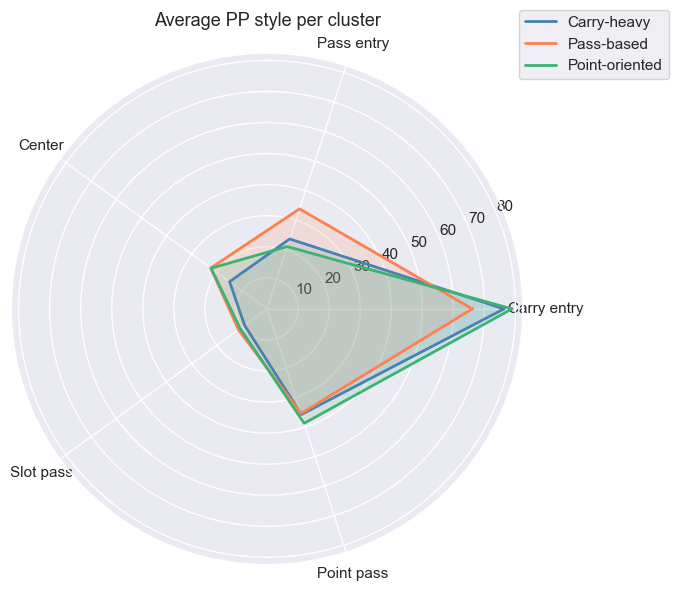

In [45]:
# Features used in radar plot
categories = ['carry_pct', 'pass_pct', 'center_pct', 'slot_pct', 'point_pct']
labels = ['Carry entry', 'Pass entry', 'Center', 'Slot pass', 'Point pass']

# Number of variables
N = len(categories)

# Compute radar chart angles
angles = [n / float(N) * 2 * np.pi for n in range(N)] + [0]
fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))

palette = ['steelblue', 'coral', 'mediumseagreen'] # Color palette

# Plot each style cluster
for i, (style, grp) in enumerate(style_df.groupby('style')):
    
    # Mean values for each feature in cluster
    vals = grp[categories].mean().tolist()
    vals += [vals[0]]  # close the circle
    
    # Plot line and fill area
    ax.plot(angles, vals, color=palette[i], linewidth=2, label=style)
    ax.fill(angles, vals, color=palette[i], alpha=0.15)

# Set axis labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, size=11)
ax.set_title('Average PP style per cluster', size=13, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))

plt.tight_layout()
plt.show()

### PP conversion rate by playing style

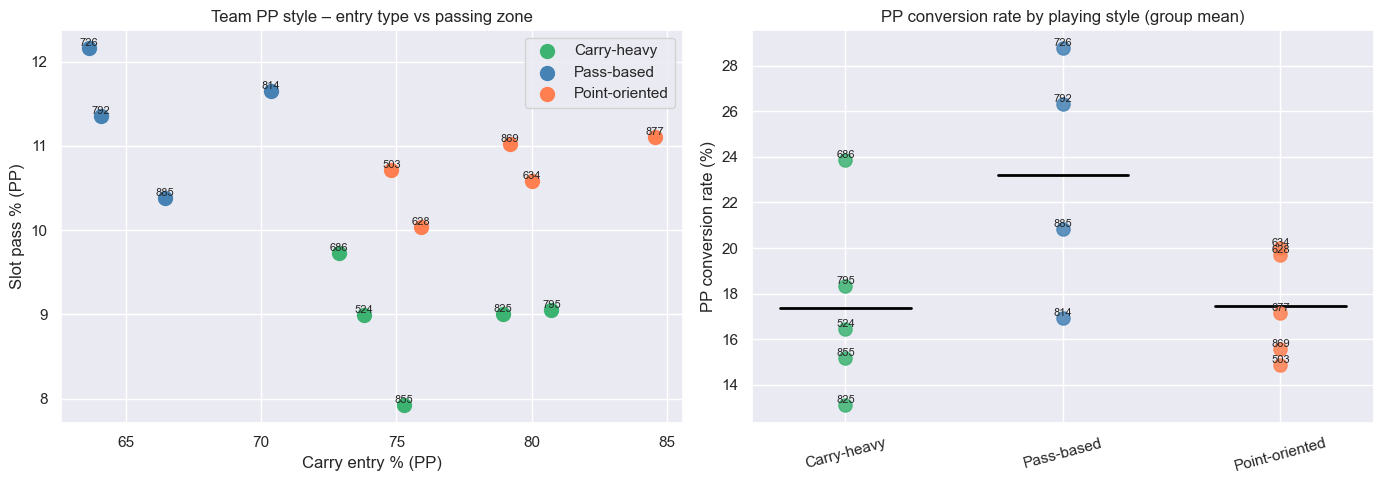

In [46]:
# Color palette for styles
palette = dict(zip(style_df['style'].unique(),
                   ['steelblue', 'coral', 'mediumseagreen']))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot left: Style space
for style, grp in style_df.groupby('style'):
    axes[0].scatter(
        grp['carry_pct'],
        grp['slot_pct'],
        label=style,
        s=100,
        color=palette.get(style, 'gray'))
    
    # Team labels
    for _, row in grp.iterrows():
        axes[0].annotate(
            str(row['teamid']),
            (row['carry_pct'], row['slot_pct']),
            fontsize=8,
            ha='center',
            va='bottom')

axes[0].set_xlabel('Carry entry % (PP)')
axes[0].set_ylabel('Slot pass % (PP)')
axes[0].set_title('Team PP style – entry type vs passing zone')
axes[0].legend()

# Plot right: PP efficiency
style_order = sorted(style_df['style'].unique())

for i, s in enumerate(style_order):
    grp = style_df[style_df['style'] == s]
    
    # teams in each style group
    axes[1].scatter(
        [i] * len(grp),
        grp['pp_pct'],
        s=90,
        color=palette.get(s, 'gray'),
        alpha=0.85,
        zorder=3)
    
    # Team labels
    for _, row in grp.iterrows():
        axes[1].annotate(
            str(row['teamid']),
            (i, row['pp_pct']),
            fontsize=8,
            ha='center',
            va='bottom')
    
    # Mean line per style group
    axes[1].plot(
        [i - 0.3, i + 0.3],
        [grp['pp_pct'].mean()] * 2,
        color='black',
        linewidth=2)

axes[1].set_xticks(range(len(style_order)))
axes[1].set_xticklabels(style_order, rotation=15)
axes[1].set_ylabel('PP conversion rate (%)')
axes[1].set_title('PP conversion rate by playing style (group mean)')

plt.tight_layout()
plt.show()

### Where shots was made from each team

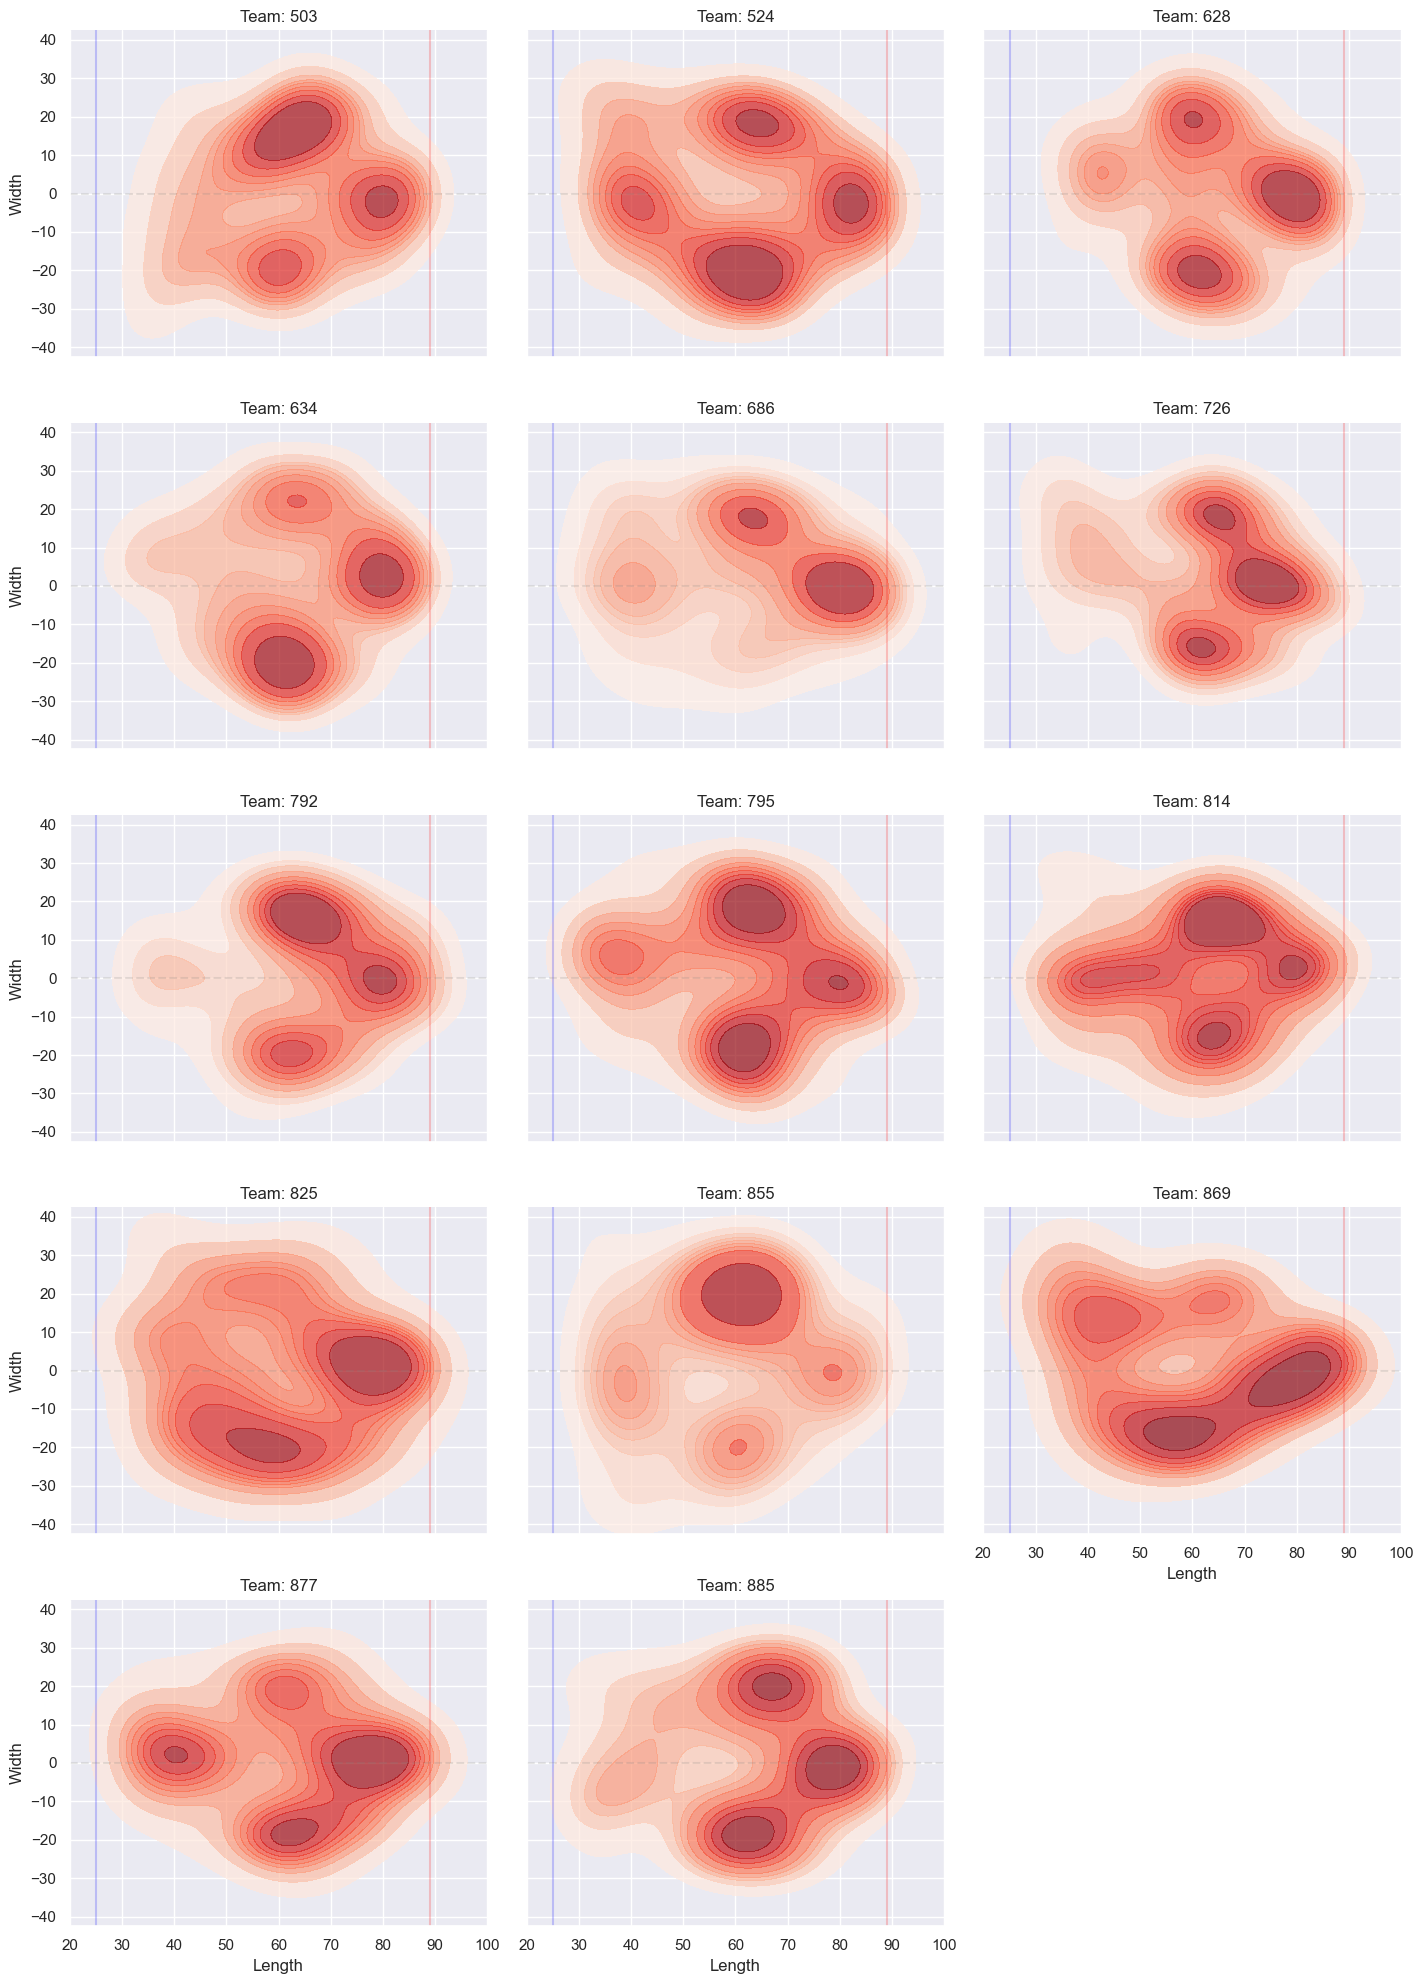

side    Left  Right  Left_Percent
teamid                           
855       91     65     58.333333
686      148    116     56.060606
726      135    114     54.216867
877       92     79     53.801170
634       76     67     53.146853
795       91     83     52.298851
814       97     90     51.871658
825       64     61     51.200000
869      101     97     51.010101
628       81     79     50.625000
885      104    102     50.485437
503      115    116     49.783550
792       71     72     49.650350
524       95    116     45.023697


In [47]:
# Sort data by game and time
df = sorted_data.sort_values(['gameid', 'compiledgametime']).copy()

# Find start of each power play
df['is_pp'] = (df['manpowersituation'] == 'powerPlay').astype(int)
df['pp_start'] = (df['is_pp'] == 1) & (df['is_pp'].shift(1) == 0)
df['pp_id'] = df.groupby('gameid')['pp_start'].cumsum()

# Filter shots in power play (shots + goals)
pp_shots = df[
    (df['manpowersituation'] == 'powerPlay') & 
    ((df['eventname'] == 'shot') | (df['eventname'] == 'goal'))
].copy()

# Get teams with most shots
top_teams = pp_shots['teamid'].value_counts().index
filter_df = pp_shots[pp_shots['teamid'].isin(top_teams)]

# Create grid of plots (one per team)
g = sns.FacetGrid(filter_df, col="teamid", col_wrap=3, height=4, aspect=1.2)

# Simple rink lines
def draw_rink_mini(*args, **kwargs):
    plt.axvline(25, color='blue', alpha=0.2)   # blue line
    plt.axvline(89, color='red', alpha=0.2)    # goal line
    plt.axhline(0, color='grey', linestyle='--', alpha=0.2)

g.map(draw_rink_mini)

# Add heatmap of shot locations
g.map_dataframe(
    sns.kdeplot,
    x="xadjcoord",
    y="yadjcoord",
    fill=True,
    cmap="Reds",
    alpha=0.7,
    thresh=0.1)

g.set(xlim=(20, 100), ylim=(-42.5, 42.5))
g.set_axis_labels("Length", "Width")
g.set_titles("Team: {col_name}")

plt.tight_layout()
plt.show()

# Create left/right side column
pp_shots['side'] = pp_shots['yadjcoord'].apply(
    lambda y: 'Left' if y > 0 else 'Right'
)

# Count shots per side and team
side_distribution = pp_shots.groupby(['teamid', 'side']).size().unstack(fill_value=0)

# Calculate left side percentage
side_distribution['Left_Percent'] = (
    side_distribution['Left'] /
    (side_distribution['Left'] + side_distribution['Right'])
) * 100

# Show result sorted by left side %
print(side_distribution.sort_values(by='Left_Percent', ascending=False))